In [4]:
import pandas as pd

df = pd.read_csv('bank-full.csv', sep=';')

print('Data loaded!')
print('Rows:', len(df))
print('Columns:', len(df.columns))
print('')
print('Column names:')
print(df.columns.tolist())

Data loaded!
Rows: 45211
Columns: 17

Column names:
['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'y']


In [5]:
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [6]:
print('Missing values:')
print(df.isnull().sum())
print('')
print('data types:')
print(df.dtypes)

Missing values:
age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

data types:
age          int64
job            str
marital        str
education      str
default        str
balance      int64
housing        str
loan           str
contact        str
day          int64
month          str
duration     int64
campaign     int64
pdays        int64
previous     int64
poutcome       str
y              str
dtype: object


In [7]:
conversion=df['y'].value_counts()
print(conversion)
print('')
conversion_rate=df['y'].value_counts(normalize=True)*100
print('Conversion rates:')
print(round(conversion_rate, 1))

y
no     39922
yes     5289
Name: count, dtype: int64

Conversion rates:
y
no     88.3
yes    11.7
Name: proportion, dtype: float64


In [9]:
# People who were called but hung up quickly vs stayed on the line
df['duration_category'] = pd.cut(df['duration'], 
                                  bins=[0, 60, 180, 300, 600, 5000],
                                  labels=['<1 min', '1-3 min', '3-5 min', '5-10 min', '10+ min'])

duration_conv = df.groupby('duration_category', observed=True)['y'].value_counts(normalize=True).unstack() * 100
print(round(duration_conv, 1))

y                    no   yes
duration_category            
<1 min             99.8   0.2
1-3 min            96.1   3.9
3-5 min            89.1  10.9
5-10 min           80.8  19.2
10+ min            51.6  48.4


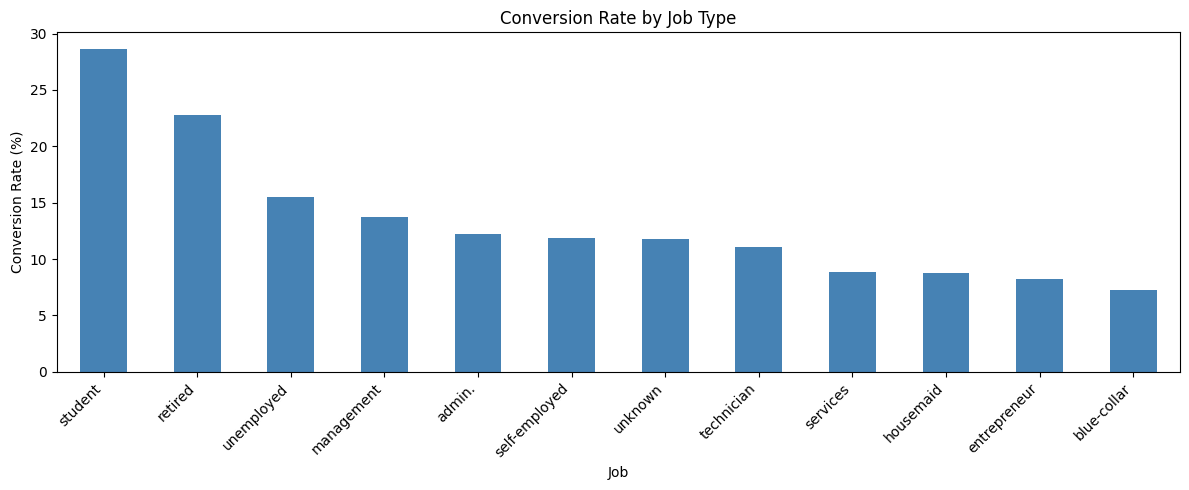

In [10]:
import matplotlib.pyplot as plt

job_conv = df.groupby('job')['y'].apply(lambda x: (x == 'yes').sum() / len(x) * 100).sort_values(ascending=False)

job_conv.plot(kind='bar', color='steelblue', figsize=(12, 5))
plt.title('Conversion Rate by Job Type')
plt.xlabel('Job')
plt.ylabel('Conversion Rate (%)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

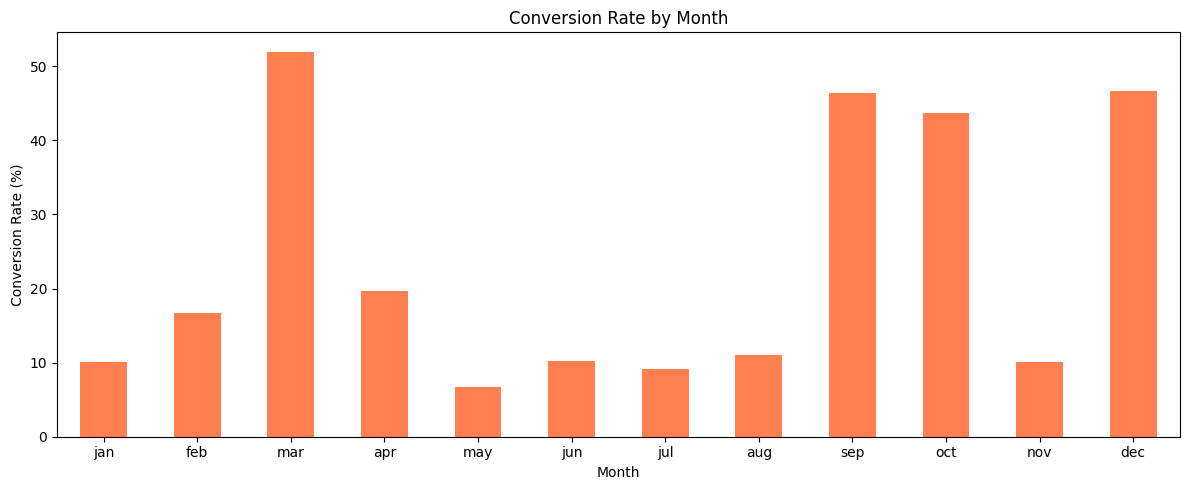

In [11]:
month_order = ['jan','feb','mar','apr','may','jun','jul','aug','sep','oct','nov','dec']
month_conv = df.groupby('month')['y'].apply(lambda x: (x == 'yes').sum() / len(x) * 100).reindex(month_order)

month_conv.plot(kind='bar', color='coral', figsize=(12, 5))
plt.title('Conversion Rate by Month')
plt.xlabel('Month')
plt.ylabel('Conversion Rate (%)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

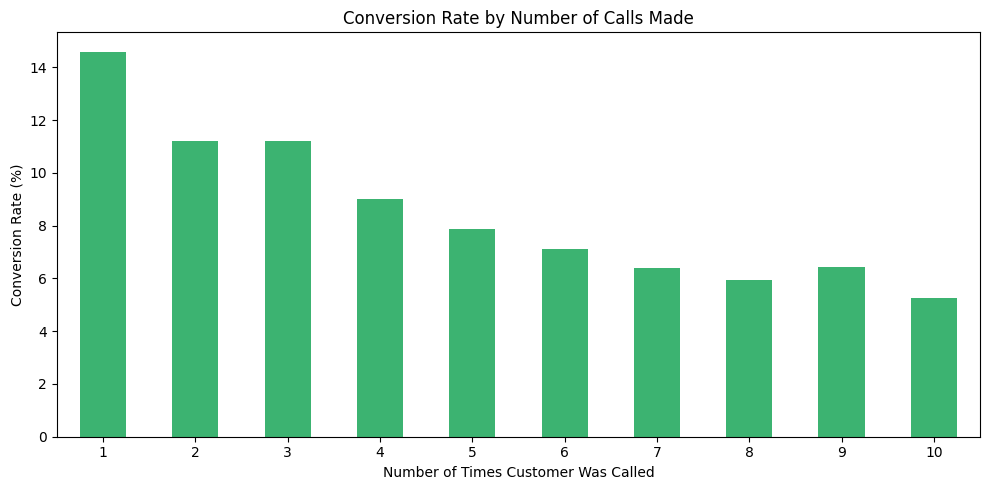

In [12]:
campaign_conv = df.groupby('campaign')['y'].apply(lambda x: (x == 'yes').sum() / len(x) * 100).head(10)

campaign_conv.plot(kind='bar', color='mediumseagreen', figsize=(10, 5))
plt.title('Conversion Rate by Number of Calls Made')
plt.xlabel('Number of Times Customer Was Called')
plt.ylabel('Conversion Rate (%)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

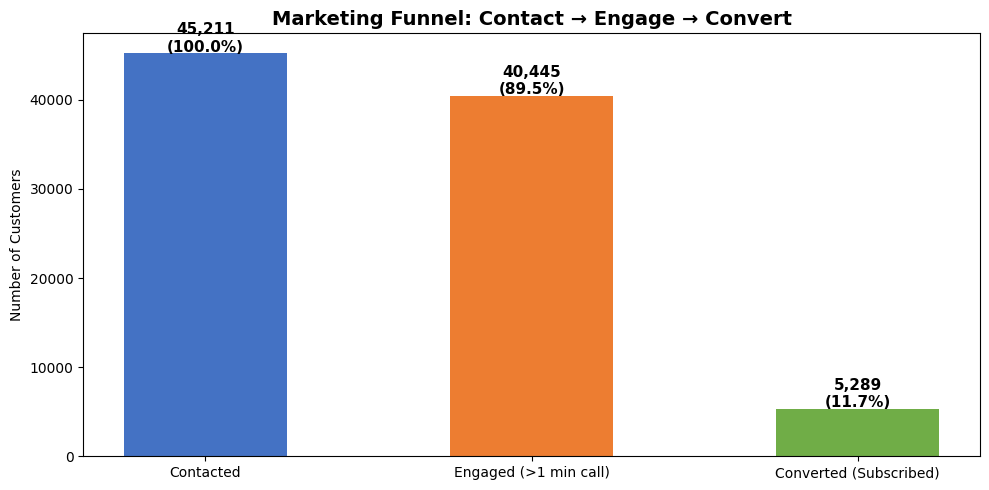

In [13]:

total = len(df)
engaged = len(df[df['duration'] > 60])
converted = len(df[df['y'] == 'yes'])

stages = ['Contacted', 'Engaged (>1 min call)', 'Converted (Subscribed)']
values = [total, engaged, converted]
colors = ['#4472C4', '#ED7D31', '#70AD47']

plt.figure(figsize=(10, 5))
bars = plt.bar(stages, values, color=colors, width=0.5)

for bar, val in zip(bars, values):
    pct = val / total * 100
    plt.text(bar.get_x() + bar.get_width()/2, val + 200,
             f'{val:,}\n({pct:.1f}%)', ha='center', fontsize=11, fontweight='bold')

plt.title('Marketing Funnel: Contact → Engage → Convert', fontsize=14, fontweight='bold')
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.show()

## Key Insights — Marketing Funnel Analysis

1. Overall conversion rate is only 11.7% — 88.3% of contacts do not convert
2. Call duration is the strongest predictor — 10+ min calls convert at over 80%
3. Students and retired customers convert at the highest rates
4. March, September and October are the best months for campaigns
5. Calling a customer more than 3 times drastically reduces conversion

## Funnel Drop-off Points
1 Contacted → Engaged: ~22% drop off within the first minute
2 Engaged → Converted: ~85% of engaged customers still don't convert

## Recommendations
1. Train agents to extend call duration — longer conversations = more conversions
2. Focus campaigns in March, September and October
3. Stop calling customers after 3 unsuccessful attempts — it wastes resources
4. Create targeted campaigns specifically for students and retirees
5. Invest more in keeping customers engaged past the first minute